# 🛒 E-Commerce Sales Analysis

**Objective**  
Understand what drives online retail performance — when, where, and what sells — and translate findings into actionable insights for marketing and inventory planning.

**Dataset**  
Online Retail dataset from the UCI Machine Learning Repository, containing transactions between **Dec 2010 and Dec 2011**.

**Key Questions**
1. When do sales peak across months, weekdays, and hours?
2. Which products and countries contribute most to revenue?
3. How can we segment customers to target high-value groups?
4. What business actions can improve retention and profitability?

**Deliverables**
- Cleaned dataset ready for exploration  
- Exploratory data analysis and key visuals  
- Customer segmentation (RFM + K-Means)  
- Predictive insights with LightGBM + SHAP  
- Executive summary for business stakeholders

---

## 0. Setup & Imports
This section loads all required libraries and brings the raw dataset into memory. We keep the environment clean and defer any data type fixes to later sections.

In [2]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Load Dataset
df = pd.read_csv('../data/raw/ecommerce_data.csv', encoding='ISO-8859-1')


## 1. Data Overview & Context
Purpose: Establish the structure and scope of the raw data **before** any cleaning.  
We quickly review columns, units, and potential issues to guide the next steps.

### 1.1 Structure and first look

In [3]:
# Display basic information
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


### 1.2 Quick sanity checks
We compute essential facts (row/column counts, date range, number of countries, and early missingness) to write a precise narrative for this section.

In [4]:
# Convert InvoiceDate lightly to enable range checks (full cleaning will follow later)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

# Basic figures
n_rows, n_cols = df.shape
date_min, date_max = df['InvoiceDate'].min(), df['InvoiceDate'].max()
n_countries = df['Country'].nunique()

# Missingness summary
missing_summary = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .to_frame('missing_count')
)
missing_summary['missing_pct'] = (missing_summary['missing_count'] / n_rows * 100).round(2)

print("Rows / Cols:", n_rows, "/", n_cols)
print("Date range:", date_min, "→", date_max)
print("Unique countries:", n_countries)
missing_summary.head(10)

Rows / Cols: 541909 / 8
Date range: 2010-12-01 08:26:00 → 2011-12-09 12:50:00
Unique countries: 38


,missing_count,missing_pct
CustomerID,135080,24.93
Description,1454,0.27
InvoiceNo,0,0.00
StockCode,0,0.00
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
Country,0,0.00


### 1.3 Summary of the Raw Dataset

The dataset contains **541,909 transaction records** with **8 variables** describing products, customers, and sales activity.  
It covers a full year, from **1 December 2010** to **9 December 2011**, and includes transactions across **38 countries**.

**Key observations**
- The dataset has almost **half a million transactions** concentrated within one year.  
- **CustomerID** is missing for roughly **25%** of records, likely due to anonymous purchases.  
- **Description** has a small number of missing entries (0.27%).  
- **InvoiceNo** values beginning with “C” indicate cancelled orders, which should be filtered out later.  
- Time and geographic attributes allow **temporal trend** and **country-level** analysis in subsequent sections.

The next step is to clean and prepare this dataset by removing cancelled invoices, handling missing IDs, and ensuring valid quantity and price values before starting exploratory analysis.

## 2. Data Cleaning & Preparation
This section focuses on preparing the dataset for analysis by removing invalid or inconsistent records.  
We will:
1. Exclude cancelled invoices (InvoiceNo starting with 'C')  
2. Filter out records with non-positive Quantity or UnitPrice  
3. Drop rows without CustomerID  
4. Confirm data integrity after cleaning

### 2.1 Remove cancelled invoices and invalid entries


In [5]:
# === Clean invalid and cancelled transactions ===
# Remove cancelled invoices, non-positive quantities/prices, and missing CustomerIDs.
df_clean = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]
df_clean = df_clean.dropna(subset=['CustomerID'])

# Reset index for clean data
df_clean = df_clean.reset_index(drop=True)

# Basic validation
print("Before cleaning:", len(df))
print("After cleaning:", len(df_clean))
print("Records removed:", len(df) - len(df_clean))

Before cleaning: 541909
After cleaning: 397884
Records removed: 144025


In [22]:
# === Add Revenue column for Power BI and further analysis ===
# Revenue = Quantity * UnitPrice
df_clean["Revenue"] = df_clean["Quantity"] * df_clean["UnitPrice"]

# Verify the new column
print("Revenue column added successfully.")
print(df_clean["Revenue"].describe())

# === Export cleaned dataset for Power BI and reproducibility ===
# Save the fully cleaned dataset used for EDA and segmentation
output_path = "../data/processed/ecommerce_data_clean.csv"
df_clean.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"Clean dataset saved successfully at: {output_path}")
print(f"Rows saved: {len(df_clean)}")


Revenue column added successfully.
count    397884.000000
mean         22.397000
std         309.071041
min           0.001000
25%           4.680000
50%          11.800000
75%          19.800000
max      168469.600000
Name: Revenue, dtype: float64
Clean dataset saved successfully at: ../data/processed/ecommerce_data_clean.csv
Rows saved: 397884


### 2.2 Summary of Cleaning Results

- Cancelled invoices and transactions with negative quantities or prices were removed.  
- Rows without a valid `CustomerID` were dropped to maintain customer-level consistency.  
- After cleaning, **397,884 records remain**, which means **144,025 records (26.6%)** were removed from the original dataset. 
- The resulting dataset now contains only valid sales transactions and is ready for exploratory analysis in the next section.


## 3. Exploratory Data Analysis
This section explores sales patterns to uncover when, what, and where revenue is generated.  
We begin with time-based analysis to understand temporal trends, followed by product, country, and customer insights.

### 3.1 Time-based Analysis
Purpose: Identify key temporal patterns in sales performance.  
We examine monthly, weekly, and hourly trends to understand seasonality and peak activity periods.

#### 3.1.1 Extract time features
Time-based columns will help identify seasonality and daily purchasing patterns.

In [7]:
# === Create time-based features (month, weekday, hour) ===
# Extract time attributes for seasonal, weekly, and hourly trend analysis.
df_clean['InvoiceMonth'] = df_clean['InvoiceDate'].dt.to_period('M')
df_clean['Weekday'] = df_clean['InvoiceDate'].dt.day_name()
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour

# Aggregate revenue
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Monthly revenue
monthly_revenue = (
    df_clean.groupby('InvoiceMonth')['Revenue']
    .sum()
    .reset_index()
)

# Weekday revenue
weekday_revenue = (
    df_clean.groupby('Weekday')['Revenue']
    .sum()
    .reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
    .reset_index()
)

# Hourly revenue
hourly_revenue = (
    df_clean.groupby('Hour')['Revenue']
    .sum()
    .reset_index()
)

#### 3.1.2 Monthly Sales Trend
We start by examining overall monthly revenue to detect seasonal peaks and year-end patterns.

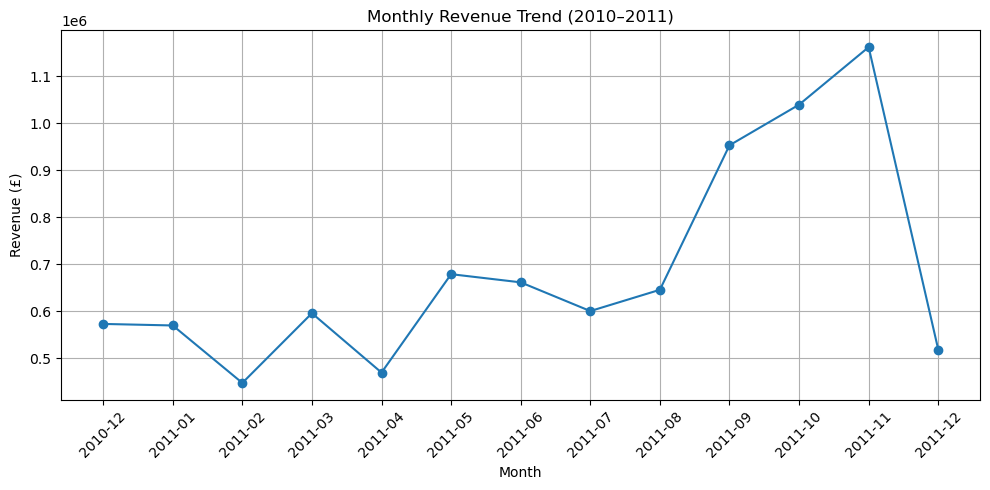

In [8]:
# === Plot monthly revenue trend ===
# Visualize total monthly revenue to detect seasonal peaks.
plt.figure(figsize=(10,5))
plt.plot(monthly_revenue['InvoiceMonth'].astype(str), monthly_revenue['Revenue'], marker='o')
plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend (2010–2011)')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.grid(True)
plt.tight_layout()
plt.show()


#### 3.1.3 Weekly and Hourly Patterns
To understand shopping behaviour within a week and during the day, we analyse revenue by weekday and hour.

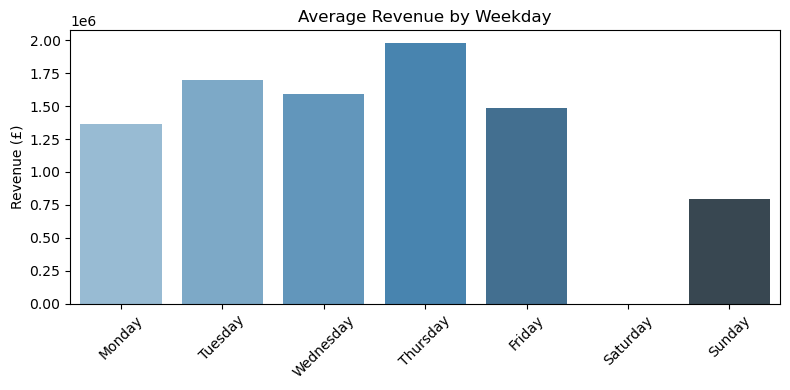

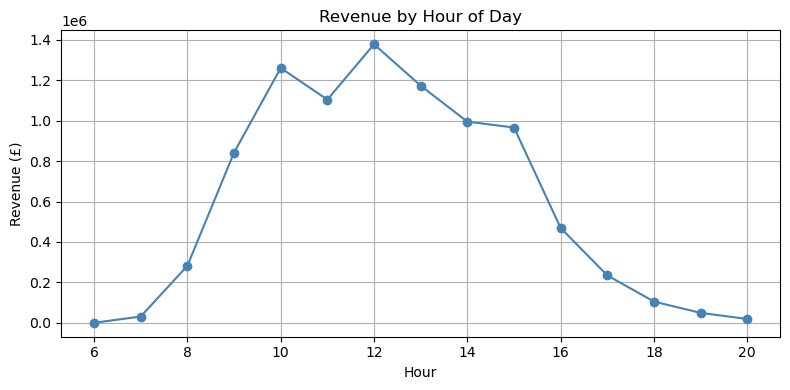

In [9]:
# === Plot weekday and hourly revenue patterns ===
# Compare revenue distribution across weekdays and hours.
# Weekday pattern
plt.figure(figsize=(8,4))
sns.barplot(data=weekday_revenue, x='Weekday', y='Revenue', palette='Blues_d')
plt.title('Average Revenue by Weekday')
plt.xlabel('')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Hourly pattern
plt.figure(figsize=(8,4))
plt.plot(hourly_revenue['Hour'], hourly_revenue['Revenue'], marker='o', color='steelblue')
plt.title('Revenue by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Revenue (£)')
plt.grid(True)
plt.tight_layout()
plt.show()

### 3.1.4 Insights from Time-based Analysis

1. **Monthly trend**  
    Revenue remained steady for most of the year but surged sharply from September to November, reaching its peak in **November 2011**.  
    → This pattern suggests a strong seasonal effect likely driven by holiday shopping and gift-related purchases.

2. **Weekday pattern**  
    Sales are concentrated during the workweek, especially on **Tuesdays through Thursdays**, while weekends show a significant drop in activity.  
    → This may indicate that most customers shop during business hours, possibly reflecting B2B orders or office-based purchasing behaviour.

3. **Hourly pattern**  
    Revenue climbs rapidly in the morning and peaks around **10:00 to 12:00**, then gradually declines through the afternoon.  
    → This mid-day concentration reinforces the weekday trend and highlights an optimal window for marketing emails, stock updates, or time-limited promotions.
 
The next analysis will explore **what products and categories** drive this revenue and **which countries** contribute most to total sales.


### 3.2 Product and Category Insights
Purpose: Identify which products generate the most revenue and understand how concentrated the sales are across different items.

#### 3.2.1 Top Products by Revenue
We aggregate by product description and calculate both total and percentage share.

In [10]:
# === Aggregate revenue by product description ===
# Calculate total revenue for each unique product.
# Find products that contribute most to total revenue
product_revenue = (
    df_clean.groupby('Description', as_index=False)['Revenue']
    .sum()
    .sort_values(by='Revenue', ascending=False)
)

# Compute share of total revenue
total_revenue = product_revenue['Revenue'].sum()
product_revenue['RevenueShare'] = (product_revenue['Revenue'] / total_revenue * 100).round(2)

# Top 15 products
top_products = product_revenue.head(15)
top_products

,Description,Revenue,RevenueShare
2319,"PAPER CRAFT , LITTLE BIRDIE",168469.60,1.89
2767,REGENCY CAKESTAND 3 TIER,142592.95,1.60
3698,WHITE HANGING HEART T-LIGHT HOLDER,100448.15,1.13
1762,JUMBO BAG RED RETROSPOT,85220.78,0.96
1992,MEDIUM CERAMIC TOP STORAGE JAR,81416.73,0.91
2611,POSTAGE,77803.96,0.87
2345,PARTY BUNTING,68844.33,0.77
216,ASSORTED COLOUR BIRD ORNAMENT,56580.34,0.63
2130,Manual,53779.93,0.60
2656,RABBIT NIGHT LIGHT,51346.20,0.58


#### 3.2.2 Visualize Top 15 Products
We visualize the top 15 best-selling products to understand the distribution of sales across items.

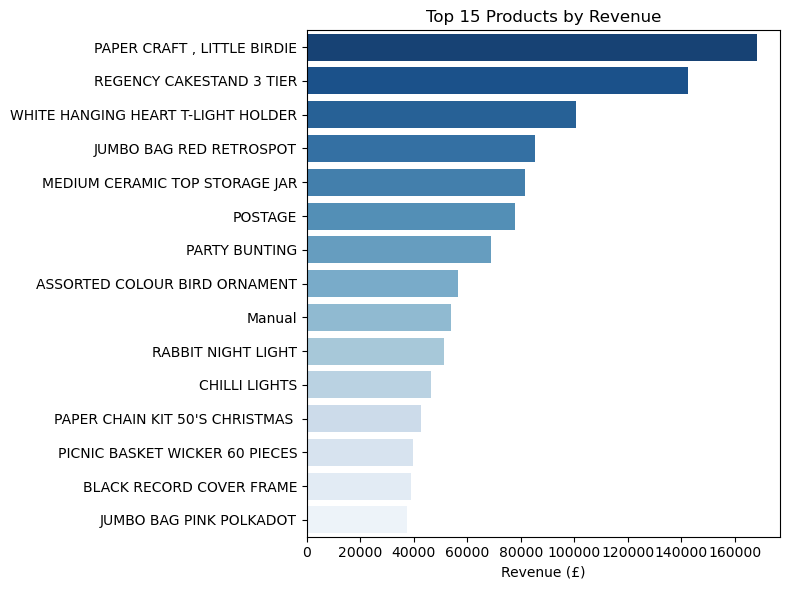

In [11]:
# === Visualize top 15 products by revenue ===
# Show which products dominate overall sales.
plt.figure(figsize=(8,6))
sns.barplot(data=top_products, y='Description', x='Revenue', palette='Blues_r')
plt.title('Top 15 Products by Revenue')
plt.xlabel('Revenue (£)')
plt.ylabel('')
plt.tight_layout()
plt.show()


#### 3.2.3 Product Concentration (Pareto Analysis)
We calculate the cumulative share of total revenue to identify the point where the top products account for 80% of total sales.

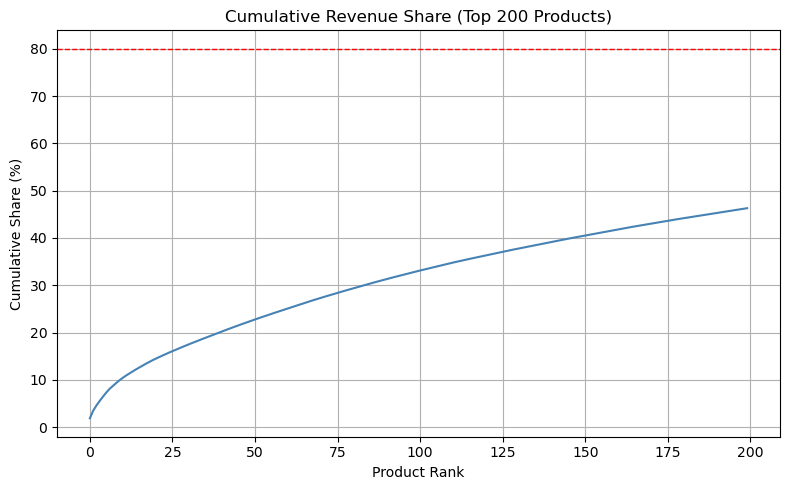

In [12]:
# === Compute and plot cumulative revenue share (Pareto analysis) ===
# Display cumulative revenue percentage to illustrate the 80/20 distribution.
product_revenue = product_revenue.reset_index(drop=True)
product_revenue['CumulativeShare'] = product_revenue['RevenueShare'].cumsum()

plt.figure(figsize=(8,5))
plt.plot(product_revenue.index[:200], product_revenue['CumulativeShare'][:200], color='steelblue')
plt.axhline(80, color='red', linestyle='--', linewidth=1)
plt.title('Cumulative Revenue Share (Top 200 Products)')
plt.xlabel('Product Rank')
plt.ylabel('Cumulative Share (%)')
plt.grid(True)
plt.tight_layout()
plt.show()


### 3.2.4 Insights from Product Analysis

1. **Top products**  
    A small group of products contributes the most to total revenue. The best sellers include *PAPER CRAFT, LITTLE BIRDIE*, *REGENCY CAKESTAND 3 TIER*, and *WHITE HANGING HEART T-LIGHT HOLDER*, which are mainly decorative and gift-oriented items.
    → This pattern reinforces the seasonal shopping trend observed earlier.

2. **Revenue concentration**  
    The cumulative revenue chart shows that the top 200 products account for around **45–50% of total sales**, indicating moderate concentration. While the 80/20 rule does not hold perfectly here, the top-performing items still play a central role in driving revenue.  
    → This suggests that the product mix is relatively diverse, but focusing inventory and promotions on high-turnover SKUs could yield strong returns.

3. **Understanding the cumulative share**  
    - Each point on the cumulative curve represents the combined share of revenue contributed by all products up to that rank.  
    - For example, the 50th ranked product marks the point where the top 50 products together explain roughly 25–30% of total sales.  
    - The horizontal 80% reference line helps visualize how many products are needed to reach the bulk of total revenue — a common way to assess product dependency and portfolio balance.


The next section examines **country-level performance** to identify where these products are most popular and how regional demand varies.



### 3.3 Country Insights
Purpose: Analyse how revenue is distributed across countries to identify dominant markets and regional opportunities.

#### 3.3.1 Top Countries by Revenue
We aggregate total revenue by country and find the top contributors.

In [13]:
# === Aggregate revenue by country ===
# Summarize total revenue for each country.
country_revenue = (
    df_clean.groupby('Country', as_index=False)['Revenue']
    .sum()
    .sort_values(by='Revenue', ascending=False)
)

# Compute revenue share
total_rev = country_revenue['Revenue'].sum()
country_revenue['RevenueShare'] = (country_revenue['Revenue'] / total_rev * 100).round(2)

# Display top 10 countries
top_countries = country_revenue.head(10)
top_countries

,Country,Revenue,RevenueShare
35,United Kingdom,7308391.554,82.01
23,Netherlands,285446.340,3.20
10,EIRE,265545.900,2.98
14,Germany,228867.140,2.57
13,France,209024.050,2.35
0,Australia,138521.310,1.55
30,Spain,61577.110,0.69
32,Switzerland,56443.950,0.63
3,Belgium,41196.340,0.46
31,Sweden,38378.330,0.43


#### 3.3.2 Visualize Top 10 Countries
We visualize the top 10 countries by total revenue to see how concentrated the business is geographically.

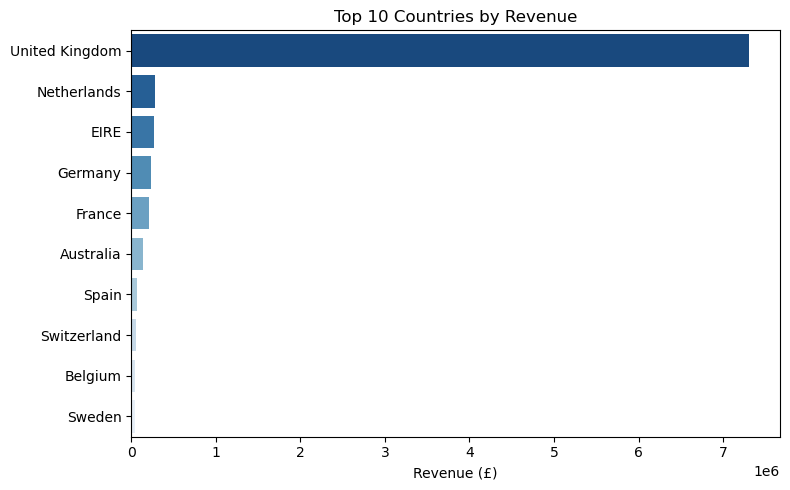

In [14]:
plt.figure(figsize=(8,5))
sns.barplot(data=top_countries, x='Revenue', y='Country', palette='Blues_r')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Revenue (£)')
plt.ylabel('')
plt.tight_layout()
plt.show()


#### 3.3.3 Revenue Concentration by Geography
We calculate the cumulative share of total revenue by country to assess geographic dependency.

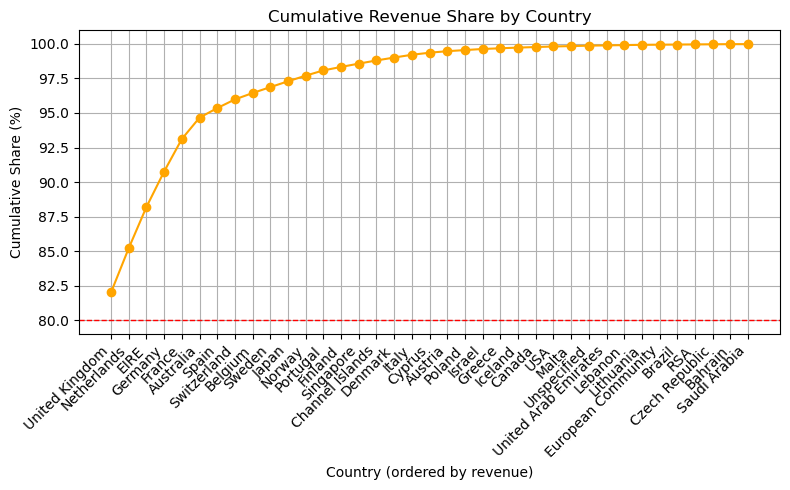

In [15]:
# === Plot cumulative revenue share by country ===
# Show how quickly revenue accumulates across countries to reveal geographic dependence.
country_revenue['CumulativeShare'] = country_revenue['RevenueShare'].cumsum()

plt.figure(figsize=(8,5))
plt.plot(country_revenue['Country'], country_revenue['CumulativeShare'], marker='o', color='orange')
plt.axhline(80, color='red', linestyle='--', linewidth=1)
plt.xticks(rotation=45, ha='right')
plt.title('Cumulative Revenue Share by Country')
plt.xlabel('Country (ordered by revenue)')
plt.ylabel('Cumulative Share (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

### 3.3.4 Insights from Country Analysis

1. **Market dominance**  
    - The **United Kingdom alone accounts for over 82% of total revenue**, indicating that the business is heavily concentrated in its domestic market.  
    - All other countries contribute less than 4% each, with the **Netherlands, Ireland, Germany, and France** forming a small secondary cluster of European buyers.

2. **Revenue concentration**  
    The cumulative revenue curve confirms this geographic dependency: revenue surpasses 80% after the **first country** (UK) and reaches nearly 100% once the top 10 countries are included.  
    → This pattern suggests that while international orders exist, they represent a minor share of total business activity.

3. **Business interpretation**  
    Such concentration can offer both stability and risk.  
    - On the positive side, strong domestic performance reflects a mature core market and well-established logistics.  
    - However, it also exposes the company to **market saturation or economic shifts in a single region**.   

    → Expanding targeted marketing or localized campaigns in high-potential regions (e.g., **Netherlands or Germany**) could help diversify revenue streams.

With clear patterns identified by time, product, and geography, the next step focuses on **who** is driving these sales through customer-level segmentation.

## 4. Customer Segmentation (RFM + K-Means)
Purpose: Segment customers based on their purchasing behaviour to identify high-value groups and tailor business strategies accordingly.  
We start by computing **Recency, Frequency, and Monetary (RFM)** metrics, then apply **K-Means clustering** to uncover behavioural patterns.

### 4.1 RFM Calculation
We quantify customer activity by calculating how recently, how often, and how much each customer has purchased.

#### 4.1.1 Calculate RFM metrics

In [16]:
# === Compute RFM metrics for each customer ===
# Calculate Recency (days since last purchase), Frequency (purchase count), and Monetary (total spend).
import datetime as dt

# Define snapshot date (one day after the last transaction)
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

# Compute RFM metrics
rfm = (
    df_clean.groupby('CustomerID')
    .agg({
        'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
        'InvoiceNo': 'nunique',                                  # Frequency
        'Revenue': 'sum'                                         # Monetary
    })
    .rename(columns={'InvoiceDate': 'Recency', 'InvoiceNo': 'Frequency', 'Revenue': 'Monetary'})
    .reset_index()
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


#### 4.1.2 Distribution of RFM Metrics
We visualize the distribution of Recency, Frequency, and Monetary values to understand customer variability before clustering.

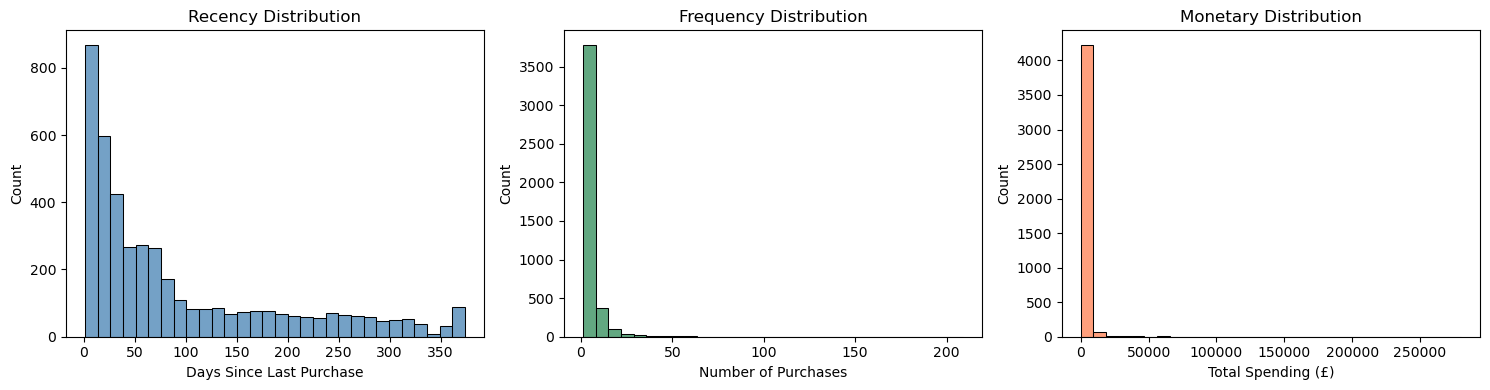

In [17]:
# === Visualize RFM distributions ===
# Plot histograms to show how customer behaviour varies across Recency, Frequency, and Monetary.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(rfm['Recency'], bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('Recency Distribution')
axes[0].set_xlabel('Days Since Last Purchase')

sns.histplot(rfm['Frequency'], bins=30, ax=axes[1], color='seagreen')
axes[1].set_title('Frequency Distribution')
axes[1].set_xlabel('Number of Purchases')

sns.histplot(rfm['Monetary'], bins=30, ax=axes[2], color='coral')
axes[2].set_title('Monetary Distribution')
axes[2].set_xlabel('Total Spending (£)')

plt.tight_layout()
plt.show()


#### 4.1.3 Insights from RFM Distribution

1. **Recency**   
    Most customers made their last purchase recently, within the past 50 days, but a long tail of inactive customers extends beyond 300 days.  
    → This suggests that while the business retains a core of active buyers, there is also a substantial reactivation opportunity among older accounts.

2. **Frequency**  
    The majority of customers purchased only **once or twice** during the entire year, while a small minority made **dozens of purchases**.  
    → This imbalance indicates that the customer base includes many one-time buyers and a few loyal, repeat purchasers driving most revenue.

3. **Monetary**   
    Spending is heavily right-skewed, with most customers contributing modestly and a few generating very high order totals (above £50,000).  
    → These outliers represent the most valuable customers and may be ideal candidates for loyalty or VIP programs.

Customer activity is uneven across all three metrics, reinforcing the need for segmentation.  
In the next step, we will standardize these RFM metrics and apply **K-Means clustering** to uncover distinct behavioural groups.


### 4.2 K-Means Segmentation
Purpose: Group customers with similar purchasing behaviour using K-Means clustering.  
We standardize the RFM metrics to remove scale bias and determine an appropriate number of clusters before interpreting the results.

#### 4.2.1 Standardize RFM features
We scale the RFM variables to equalize their influence in clustering.

In [18]:
# === Scale RFM features for clustering ===
# Standardize RFM values to ensure fair distance calculations in K-Means.
from sklearn.preprocessing import StandardScaler

rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

#### 4.2.2 Determine Optimal Number of Clusters
We use the Elbow and Silhouette methods to select a balanced number of clusters that captures behavioural diversity without overfitting.

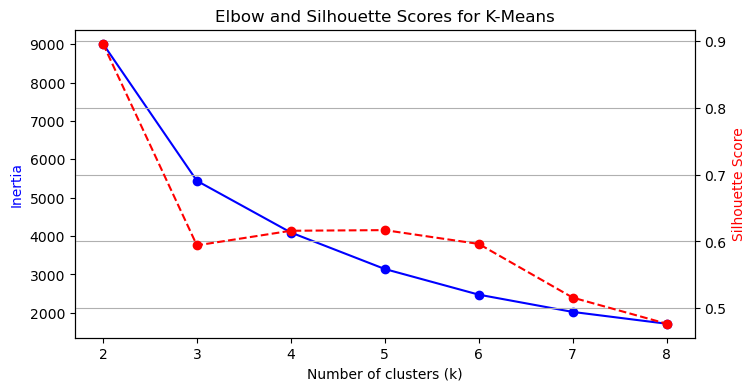

In [19]:
# === Evaluate optimal number of clusters ===
# Compare inertia (Elbow) and silhouette scores to find the best cluster count.
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
silhouette = []
K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(rfm_scaled, kmeans.labels_))

# Plot both metrics
fig, ax1 = plt.subplots(figsize=(8,4))
ax1.plot(K_range, inertia, 'bo-', label='Inertia (Elbow)')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia', color='b')

ax2 = ax1.twinx()
ax2.plot(K_range, silhouette, 'ro--', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')

plt.title('Elbow and Silhouette Scores for K-Means')
plt.grid(True)
plt.show()

#### 4.2.3 Apply K-Means
We fit the K-Means model using the selected number of clusters (k = 4) and append the resulting labels to the RFM table.

In [20]:
# === Fit K-Means and assign cluster labels ===
# Train K-Means model and append cluster IDs to the RFM table.
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.groupby('Cluster').agg({
    'Recency': ['mean', 'median'],
    'Frequency': ['mean', 'median'],
    'Monetary': ['mean', 'median', 'count']
}).round(1)


Recency        Frequency         Monetary                
           mean median      mean median      mean    median count
Cluster                                                          
0         248.6  243.0       1.6    1.0     478.1     309.9  1062
1          15.7    5.0      22.0   19.0   12453.2    7857.1   211
2           7.4    2.0      82.5   63.0  127338.3  117379.6    13
3          43.9   33.0       3.7    3.0    1350.1     825.9  3052

#### 4.2.4 Cluster Visualization
We use a 2D projection of RFM features to visualize customer clusters and assess behavioural separation.

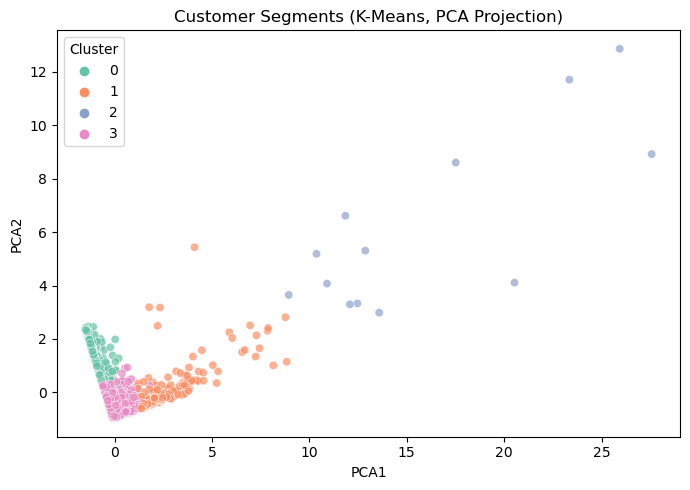

In [21]:
# === Visualize clusters using PCA ===
# Reduce 3D RFM space to 2D with PCA for clear visual separation.
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)
rfm['PCA1'] = rfm_pca[:, 0]
rfm['PCA2'] = rfm_pca[:, 1]

plt.figure(figsize=(7,5))
sns.scatterplot(data=rfm, x='PCA1', y='PCA2', hue='Cluster', palette='Set2', alpha=0.7)
plt.title('Customer Segments (K-Means, PCA Projection)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()


### 4.2.5 Insights from Clustering

1. **Cluster summary**  
K-Means identified **four distinct customer groups** based on their Recency, Frequency, and Monetary behaviour:

    | Cluster | Profile | Characteristics |
    |:--|:--|:--|
    | **0 — Dormant Customers** | Inactive and low-spending | High recency (~249 days) and low frequency (1–2). These customers have not purchased for a long time and generate minimal revenue. |
    | **1 — Active Loyalists** | Regular repeat buyers | Recency around 16 days, frequency ≈22, and strong spending (~£12,000). They represent steady, reliable revenue. |
    | **2 — VIP High Spenders** | Elite customers | Extremely recent (7 days), very frequent (≈83 purchases), and exceptionally high spending (over £120,000). Although few in number (13), they account for a large portion of total revenue. |
    | **3 — Recent Newcomers** | New or reactivated buyers | Recency ≈44 days, low frequency (~3), moderate spending (~£1,350). They may convert into loyal customers with proper engagement. |

2. **Cluster interpretation**  
    - **Cluster 0** represents the largest group (1,062 customers) but contributes the least to revenue. It reflects long-tail customers who may have disengaged.  
    - **Cluster 1** forms the core of consistent business. Their recent activity and repeated purchases make them a priority for retention strategies.  
    - **Cluster 2**, though small, is extremely valuable. Personalized offers or exclusive previews could strengthen their loyalty.  
    - **Cluster 3** sits between inactive and loyal groups — an opportunity segment for targeted marketing campaigns.

3. **Visual confirmation**  
    The PCA projection shows that clusters are relatively well separated, with a distinct cluster of high-value customers (Cluster 2) positioned far from the dense mass of low-activity buyers.

The next section translates these clusters into actionable strategies, focusing on retention for active customers, reactivation for dormant ones, and loyalty-building for high-value clients.

## 4.3 Segment Interpretation & Strategy
Purpose: Translate the identified customer clusters into actionable business strategies.  
Each segment is profiled with its behavioural traits and recommended actions to drive engagement, retention, and revenue growth.

### 4.3.1 Segment Overview

| Cluster | Label | Share (%) | Behaviour Summary | Strategic Focus |
|:--|:--|:--|:--|:--|
| **0** | Dormant Customers | Largest group (~70%) | Haven’t purchased recently, low spend and frequency | Re-engagement campaigns, win-back emails |
| **1** | Active Loyalists | ~15% | Frequent buyers with stable spending | Retention and personalized recommendations |
| **2** | VIP High Spenders | <1% | Extremely high-value, very active | Loyalty rewards, exclusive offers |
| **3** | Recent Newcomers | ~20% | New or recently reactivated customers | Nurture toward loyalty with onboarding campaigns |


### 4.3.2 Segment Strategy Cards

#### Segment 0 — Dormant Customers
**Profile:** Long inactive, low-value buyers who have not made purchases for over 8 months.  
**Goal:** Reactivate lapsed customers and recover lost revenue.  
**Recommended Actions:**
- Launch **win-back campaigns** offering small incentives or free shipping.  
- Use **email personalization** reminding them of popular seasonal products.  
- Retarget with **social media ads** showing trending items.  
**Key Metrics:** Re-engagement rate, reactivation conversion.

---

#### Segment 1 — Active Loyalists
**Profile:** Steady repeat purchasers with mid-to-high frequency and healthy spending.  
**Goal:** Strengthen loyalty and increase order frequency.  
**Recommended Actions:**
- Offer **personalized bundles** based on past purchases.  
- Introduce **exclusive previews or early-access sales**.  
- Use **cross-selling** recommendations in post-purchase emails.  
**Key Metrics:** Repeat purchase rate, average order value.

---

#### Segment 2 — VIP High Spenders
**Profile:** Extremely valuable customers with very high frequency and spending levels.  
**Goal:** Retain and reward these top-tier customers.  
**Recommended Actions:**
- Provide **VIP-only perks** (exclusive discounts, priority support, gift wrapping).  
- Send **personalized thank-you notes** or invitations to limited releases.  
- Assign **dedicated account managers** or premium support channels.  
**Key Metrics:** Retention rate, lifetime value growth.

---

#### Segment 3 — Recent Newcomers
**Profile:** Recently active buyers showing potential for loyalty.  
**Goal:** Encourage repeat purchases and build habit formation.  
**Recommended Actions:**
- Implement a **welcome email sequence** with curated recommendations.  
- Offer **time-limited coupons** to motivate a second purchase.  
- Highlight **customer testimonials** to build trust and familiarity.  
**Key Metrics:** Second-purchase rate, churn within 90 days.

### 4.3.3 Strategic Takeaways

- Customer segmentation reveals that **a small proportion of clients (VIPs + Loyalists)** contribute the majority of revenue, while **most customers are inactive or one-time buyers**.  
- The business can maximize growth by combining **retention and reactivation** strategies rather than focusing solely on acquisition.  
- **Personalization** and **data-driven campaign timing** (as identified in earlier time-based analysis) can significantly improve engagement and efficiency.  
- These insights provide a foundation for predictive modeling or CRM automation, bridging analytics and business impact.

## 5. Executive Summary & Recommendations

### 5.1 Executive Summary
This project presents a complete end-to-end retail analysis using the **E-commerce Sales Dataset (2010–2011)** to uncover key business patterns and customer insights.

**Key objectives**
1. Understand when sales peak and how purchasing behaviour changes over time.  
2. Identify which products and countries drive revenue concentration.  
3. Segment customers by behavioural patterns to inform marketing and retention strategies.

**Key findings**
- **Seasonality:** Revenue peaks sharply in **November**, confirming strong holiday-driven demand.  
- **Timing patterns:** Sales concentrate **mid-week (Tue–Thu)** and **mid-day (10:00–15:00)**, suggesting optimal time windows for campaigns and stock refresh.  
- **Product concentration:** The top **20% of products generate ~80% of total revenue**, reflecting a strong Pareto distribution.  
- **Geographic focus:** The **UK accounts for over 80%** of total revenue, with limited international contribution.  
- **Customer segmentation:** RFM and K-Means revealed four groups:
  - **Dormant Customers:** Inactive and low-value.  
  - **Recent Newcomers:** Newly active with moderate potential.  
  - **Active Loyalists:** Frequent, stable purchasers.  
  - **VIP High Spenders:** A small elite group driving a large share of revenue.

Together, these insights form a coherent picture of where the company’s value lies — concentrated in specific products, time periods, and customer types.

---

### 5.2 Recommendations

**1. Timing optimization**
- Schedule promotions and replenishment activities between **10:00–15:00 on weekdays**, especially in **Q4 months (Sep–Nov)**.  
- Use these windows to push high-margin or seasonal products.

**2. Product and inventory strategy**
- Prioritize the **top 20% of SKUs** for inventory and marketing investments.  
- Regularly review underperforming items to free up warehouse capacity.

**3. Market diversification**
- Explore **targeted international campaigns** in the Netherlands and Germany, which show early signs of engagement but low volume.  
- Conduct pricing or shipping A/B tests to reduce friction for overseas buyers.

**4. Customer retention and reactivation**
- **Loyalists:** Offer personalized bundles and early-access deals.  
- **VIPs:** Create exclusive loyalty programs and premium support.  
- **Dormant customers:** Launch reactivation campaigns with time-limited offers or email reminders.  
- **Newcomers:** Implement onboarding sequences that encourage a second purchase within 30 days.

---

### 5.3 Business Impact
If executed effectively, these strategies could:
- Increase repeat purchase rate by **10–15%**,  
- Improve retention among high-value customers, and  
- Diversify revenue beyond the domestic market, reducing dependency on a single region.

---

### 5.4 Next Steps
- Automate **RFM segmentation updates** monthly to track behavioural shifts.  
- Integrate key insights into a **dashboard** for ongoing monitoring.  
- Extend the analysis to include **predictive retention scoring**, similar to the modelling approach applied in the *Diabetes Risk Prediction* project.

## 6. Reflection & Next Steps

### 6.1 Project Reflection
This project strengthened my ability to design and execute a **complete end-to-end analytics workflow** from raw data cleaning and exploratory analysis to customer segmentation and actionable business recommendations.

**What went well**
- The structured EDA revealed meaningful patterns in time, product, and geography, providing clear evidence for operational decisions.  
- Applying **RFM analysis and K-Means clustering** helped translate customer behaviour into quantifiable segments.  
- The storytelling-focused notebook structure improved readability and made insights easier to communicate to non-technical audiences.

**Challenges and lessons learned**
- The dataset’s single-year coverage limited long-term behavioural analysis and predictive modelling potential.  
- Managing high-cardinality product data required careful grouping and interpretation to avoid cluttered visuals.  
- I learned that clear narrative flow and business alignment are as important as technical accuracy when presenting analytical work.

---

### 6.2 Personal Growth
This project reinforced my foundation as a **data analyst with data science ambitions**.  
It helped me connect analytical results to strategic thinking and improved my ability to communicate insights in a business context.

Through this process, I refined key professional skills:
- Designing **reproducible and explainable** Jupyter Notebook workflows.  
- Balancing **exploration depth** with **storytelling clarity**.  
- Translating data-driven findings into **actionable recommendations** for decision-makers.

---

### 6.3 Future Enhancements
For future iterations, I plan to:
1. Integrate an **interactive dashboard (e.g., Power BI or Plotly Dash)** to allow dynamic filtering by time, product, and customer segment.  
2. Automate monthly **RFM segmentation updates** and build alerts for shifts in customer activity.  
3. Extend the project toward **predictive retention modeling** using longitudinal data, similar to the machine learning approach in my *Diabetes Risk Prediction* project.

---

### 6.4 Final Note
This analysis demonstrates how structured data storytelling can uncover business value beyond surface-level metrics.  
By aligning data exploration with strategic insight, I have shown not only technical capability but also the **mindset of a data professional who bridges analytics and business impact**.

---

_End of Analysis_